# Notebook 06: Mortality Validation
## Wearable-Enhanced Insurance Underwriting — NHANES 2003-2004

**Author:** Lubaba Hassan | 22097014D | PolyU Data Science and Analytics

### Purpose
This notebook links **real mortality outcomes** (CDC Linked Mortality File,
follow-up through Dec 31, 2019 — approximately 15 years) to our baseline
classifier predictions and wearable features. It asks three questions:

1. **Label validation:** Do participants classified as High risk by our
   Framingham-based label actually die at higher rates?
2. **Classifier validation:** Do participants *predicted* as High risk by
   our best model die at higher rates than those predicted as Low risk?
3. **Wearable signal:** Among participants classified as Low risk at baseline,
   do those with lower physical activity experience higher mortality? If so,
   wearable data identifies future risk that current clinical classification misses.

### Why This Matters for Insurance
Underwriting models predict future claims. The strongest possible validation
is whether the model's risk classifications align with **actual mortality**
over a multi-year horizon. This is the evidence an insurer would need before
trusting an ML model for pricing decisions.

## 1. Imports and Configuration

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from scipy import stats

# Display settings
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)

# Paths
DATA_PATH = '../data/processed/'
FIGURES_PATH = '../reports/figures/'
RESULTS_PATH = '../results/'
os.makedirs(FIGURES_PATH, exist_ok=True)
os.makedirs(RESULTS_PATH, exist_ok=True)

print('All imports successful.')

All imports successful.


## 2. Load and Merge Mortality Data

In [4]:
# Load mortality file
mort = pd.read_csv(DATA_PATH + 'NHANES_2003_2004_mortality.csv')
print(f'Mortality file: {len(mort):,} total records')

# Keep only eligible adults with known mortality status
mort_eligible = mort[mort['ELIGSTAT'] == 1].copy()
mort_eligible = mort_eligible.dropna(subset=['MORTSTAT'])
mort_eligible['deceased'] = mort_eligible['MORTSTAT'].astype(int)
mort_eligible['follow_years'] = mort_eligible['PERMTH_INT'] / 12

print(f'Eligible with known mortality: {len(mort_eligible):,}')
print(f'  Alive: {(mort_eligible["deceased"] == 0).sum():,}')
print(f'  Deceased: {(mort_eligible["deceased"] == 1).sum():,}')
print(f'  Mortality rate: {mort_eligible["deceased"].mean():.1%}')
print(f'  Median follow-up: {mort_eligible["follow_years"].median():.1f} years')

Mortality file: 10,122 total records
Eligible with known mortality: 5,610
  Alive: 4,190
  Deceased: 1,420
  Mortality rate: 25.3%
  Median follow-up: 15.8 years


In [5]:
# Load scenario datasets
scenario_a = pd.read_csv(DATA_PATH + 'scenario_a.csv')
scenario_b = pd.read_csv(DATA_PATH + 'scenario_b.csv')

# Merge mortality with Scenario A (largest dataset)
df_a = scenario_a.merge(
    mort_eligible[['SEQN', 'deceased', 'follow_years', 'UCOD_LEADING',
                   'PERMTH_INT']],
    on='SEQN', how='inner'
)

# Merge mortality with Scenario B (has wearable features)
df_b = scenario_b.merge(
    mort_eligible[['SEQN', 'deceased', 'follow_years', 'UCOD_LEADING',
                   'PERMTH_INT']],
    on='SEQN', how='inner'
)

print(f'\nScenario A + mortality: {len(df_a):,} participants')
print(f'  Mortality rate: {df_a["deceased"].mean():.1%}')
print(f'  Risk class distribution:')
print(f'    {df_a["risk_class"].value_counts().sort_index().to_dict()}')

print(f'\nScenario B + mortality: {len(df_b):,} participants')
print(f'  Mortality rate: {df_b["deceased"].mean():.1%}')
print(f'  Risk class distribution:')
print(f'    {df_b["risk_class"].value_counts().sort_index().to_dict()}')


Scenario A + mortality: 3,380 participants
  Mortality rate: 31.3%
  Risk class distribution:
    {0: 1344, 1: 702, 2: 1334}

Scenario B + mortality: 1,883 participants
  Mortality rate: 24.8%
  Risk class distribution:
    {0: 839, 1: 381, 2: 663}


## 3. Label Validation: Do Framingham Risk Classes Predict Actual Mortality?

This is the most fundamental check. If participants labelled as High risk
don't actually die at higher rates, the entire modelling exercise is moot.

In [6]:
# ── Mortality rate by risk class ─────────────────────────────
CLASS_NAMES = {0: 'Low', 1: 'Intermediate', 2: 'High'}

print('=' * 70)
print('MORTALITY RATE BY FRAMINGHAM RISK CLASS (Scenario A)')
print('=' * 70)

label_mort = df_a.groupby('risk_class').agg(
    n=('deceased', 'count'),
    deaths=('deceased', 'sum'),
    mortality_rate=('deceased', 'mean'),
    mean_follow_years=('follow_years', 'mean')
).round(4)

label_mort.index = label_mort.index.map(CLASS_NAMES)
print(label_mort)

# Chi-square test: is mortality rate significantly different across classes?
contingency = pd.crosstab(df_a['risk_class'], df_a['deceased'])
chi2, p_value, dof, expected = stats.chi2_contingency(contingency)
print(f'\nChi-square test: χ²={chi2:.2f}, p={p_value:.2e}, dof={dof}')
if p_value < 0.001:
    print('  → Highly significant: risk classes predict mortality (p < 0.001)')

# Risk ratio: High vs Low
mort_high = df_a[df_a['risk_class'] == 2]['deceased'].mean()
mort_low = df_a[df_a['risk_class'] == 0]['deceased'].mean()
if mort_low > 0:
    risk_ratio = mort_high / mort_low
    print(f'\nRisk ratio (High/Low): {risk_ratio:.2f}x')
    print(f'  High-risk mortality: {mort_high:.1%}')
    print(f'  Low-risk mortality: {mort_low:.1%}')

MORTALITY RATE BY FRAMINGHAM RISK CLASS (Scenario A)
                 n  deaths  mortality_rate  mean_follow_years
risk_class                                                   
Low           1344     190          0.1414            15.0868
Intermediate   702     158          0.2251            14.4157
High          1334     711          0.5330            11.8797

Chi-square test: χ²=509.29, p=2.56e-111, dof=2
  → Highly significant: risk classes predict mortality (p < 0.001)

Risk ratio (High/Low): 3.77x
  High-risk mortality: 53.3%
  Low-risk mortality: 14.1%


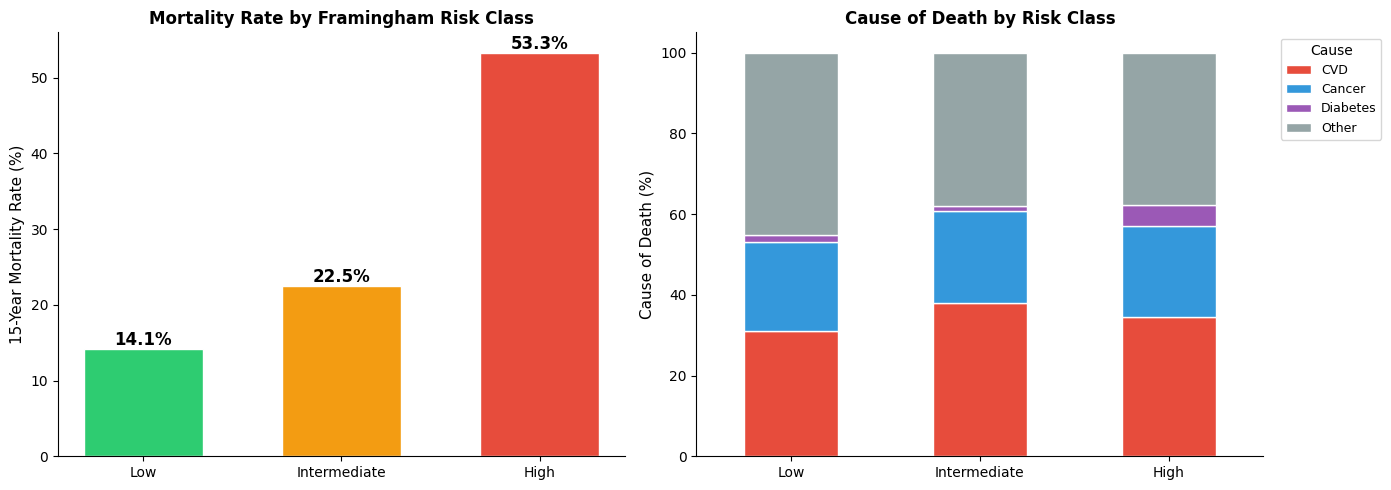

Saved: mortality_by_risk_class.png


In [7]:
# ── Figure 1: Mortality by risk class ────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Bar chart of mortality rate
ax = axes[0]
class_order = ['Low', 'Intermediate', 'High']
class_colors = ['#2ecc71', '#f39c12', '#e74c3c']
mort_rates = [df_a[df_a['risk_class'] == i]['deceased'].mean() * 100
              for i in range(3)]
bars = ax.bar(class_order, mort_rates, color=class_colors, edgecolor='white',
              width=0.6)
for bar, rate in zip(bars, mort_rates):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('15-Year Mortality Rate (%)', fontsize=11)
ax.set_title('Mortality Rate by Framingham Risk Class', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: Cause of death breakdown by risk class
ax = axes[1]
cod_map = {1: 'Heart disease', 2: 'Cancer', 5: 'Stroke',
           7: 'Diabetes', 10: 'Other'}
# Simplify: group into CVD, Cancer, Other
dead = df_a[df_a['deceased'] == 1].copy()
dead['cause_group'] = dead['UCOD_LEADING'].map({
    1: 'CVD', 5: 'CVD', 2: 'Cancer', 7: 'Diabetes'
}).fillna('Other')

cause_by_class = pd.crosstab(
    dead['risk_class'].map(CLASS_NAMES),
    dead['cause_group'],
    normalize='index'
) * 100

cause_colors = {'CVD': '#e74c3c', 'Cancer': '#3498db',
                'Diabetes': '#9b59b6', 'Other': '#95a5a6'}
cause_by_class = cause_by_class.reindex(class_order)
cause_by_class.plot(kind='bar', stacked=True, ax=ax,
                    color=[cause_colors.get(c, '#95a5a6') for c in cause_by_class.columns],
                    edgecolor='white')
ax.set_ylabel('Cause of Death (%)', fontsize=11)
ax.set_title('Cause of Death by Risk Class', fontweight='bold')
ax.set_xlabel('')
ax.tick_params(axis='x', rotation=0)
ax.legend(title='Cause', bbox_to_anchor=(1.02, 1), fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'mortality_by_risk_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mortality_by_risk_class.png')

## 4. Classifier Validation: Do Model Predictions Align With Mortality?

We retrain the best model (XGBoost) on the full training set and check
whether its *predicted* risk classes align with actual mortality outcomes
on the test set.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight

RANDOM_STATE = 42

TRADITIONAL_FEATURES = [
    'age', 'male', 'bmi', 'waist_cm',
    'systolic_bp', 'diastolic_bp',
    'total_cholesterol', 'hdl_cholesterol',
    'ever_smoker', 'self_rated_health',
    'daily_activity_level', 'high_chol_told',
    'bp_hypertension_measured'
]

WEARABLE_FEATURES = [
    'total_met_hours', 'mean_met', 'total_activities',
    'moderate_count', 'vigorous_count', 'vigorous_ratio',
    'activity_category'
]

# ── Train XGBoost on Scenario A (full data) ──────────────────
X_a = df_a[TRADITIONAL_FEATURES]
y_a = df_a['risk_class']

X_train_a, X_test_a, y_train_a, y_test_a = train_test_split(
    X_a, y_a, test_size=0.2, stratify=y_a, random_state=RANDOM_STATE
)

# Align mortality outcomes with test indices
test_mort_a = df_a.loc[X_test_a.index, 'deceased'].values
test_follow_a = df_a.loc[X_test_a.index, 'follow_years'].values

xgb_a = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=RANDOM_STATE
)
sw_a = compute_sample_weight('balanced', y_train_a)
xgb_a.fit(X_train_a, y_train_a, sample_weight=sw_a)
pred_a = xgb_a.predict(X_test_a)

print('XGBoost Scenario A trained.')
print(f'Test set size: {len(X_test_a)}')

# ── Train XGBoost on Scenario B ──────────────────────────────
X_b = df_b[TRADITIONAL_FEATURES + WEARABLE_FEATURES]
y_b = df_b['risk_class']

X_train_b, X_test_b, y_train_b, y_test_b = train_test_split(
    X_b, y_b, test_size=0.2, stratify=y_b, random_state=RANDOM_STATE
)

test_mort_b = df_b.loc[X_test_b.index, 'deceased'].values
test_follow_b = df_b.loc[X_test_b.index, 'follow_years'].values

xgb_b = XGBClassifier(
    n_estimators=200, max_depth=6, learning_rate=0.1,
    subsample=0.8, colsample_bytree=0.8,
    eval_metric='mlogloss', use_label_encoder=False,
    random_state=RANDOM_STATE
)
sw_b = compute_sample_weight('balanced', y_train_b)
xgb_b.fit(X_train_b, y_train_b, sample_weight=sw_b)
pred_b = xgb_b.predict(X_test_b)

print(f'XGBoost Scenario B trained.')
print(f'Test set size: {len(X_test_b)}')

XGBoost Scenario A trained.
Test set size: 676
XGBoost Scenario B trained.
Test set size: 377


In [9]:
# ── Mortality by predicted risk class ────────────────────────
print('=' * 70)
print('MORTALITY BY PREDICTED RISK CLASS — XGBoost')
print('=' * 70)

for label, preds, morts, follows in [
    ('Scenario A', pred_a, test_mort_a, test_follow_a),
    ('Scenario B', pred_b, test_mort_b, test_follow_b)
]:
    print(f'\n--- {label} ---')
    pred_df = pd.DataFrame({
        'predicted_class': preds,
        'deceased': morts,
        'follow_years': follows
    })
    
    for cls in [0, 1, 2]:
        subset = pred_df[pred_df['predicted_class'] == cls]
        if len(subset) > 0:
            rate = subset['deceased'].mean()
            print(f'  Predicted {CLASS_NAMES[cls]:15s}: n={len(subset):4d}, '
                  f'deaths={int(subset["deceased"].sum()):3d}, '
                  f'mortality={rate:.1%}')
    
    # Risk ratio predicted High vs Low
    pred_high_mort = pred_df[pred_df['predicted_class'] == 2]['deceased'].mean()
    pred_low_mort = pred_df[pred_df['predicted_class'] == 0]['deceased'].mean()
    if pred_low_mort > 0:
        print(f'  Risk ratio (pred High/Low): {pred_high_mort/pred_low_mort:.2f}x')

MORTALITY BY PREDICTED RISK CLASS — XGBoost

--- Scenario A ---
  Predicted Low            : n= 284, deaths= 38, mortality=13.4%
  Predicted Intermediate   : n= 156, deaths= 40, mortality=25.6%
  Predicted High           : n= 236, deaths=123, mortality=52.1%
  Risk ratio (pred High/Low): 3.90x

--- Scenario B ---
  Predicted Low            : n= 174, deaths= 21, mortality=12.1%
  Predicted Intermediate   : n=  77, deaths= 12, mortality=15.6%
  Predicted High           : n= 126, deaths= 62, mortality=49.2%
  Risk ratio (pred High/Low): 4.08x


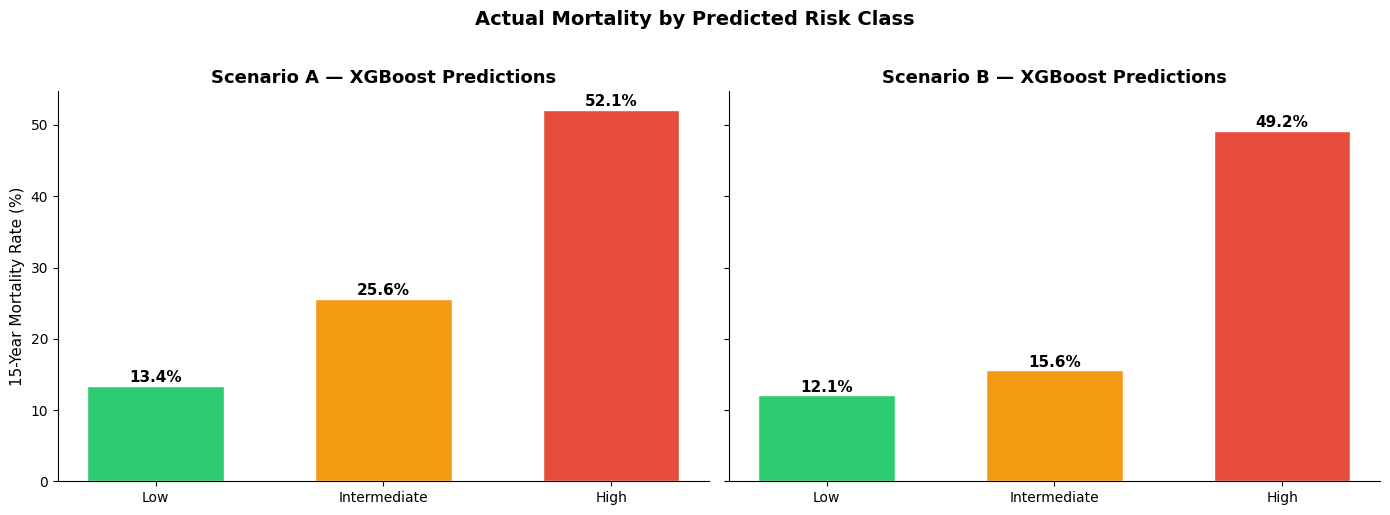

Saved: mortality_by_predicted_class.png


In [10]:
# ── Figure 2: Predicted class vs actual mortality ─────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

for idx, (label, preds, morts) in enumerate([
    ('Scenario A', pred_a, test_mort_a),
    ('Scenario B', pred_b, test_mort_b)
]):
    ax = axes[idx]
    rates = []
    for cls in [0, 1, 2]:
        mask = preds == cls
        if mask.sum() > 0:
            rates.append(morts[mask].mean() * 100)
        else:
            rates.append(0)
    
    bars = ax.bar(class_order, rates, color=class_colors, edgecolor='white', width=0.6)
    for bar, rate in zip(bars, rates):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=11)
    
    ax.set_title(f'{label} — XGBoost Predictions', fontweight='bold', fontsize=13)
    ax.set_ylabel('15-Year Mortality Rate (%)' if idx == 0 else '', fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

fig.suptitle('Actual Mortality by Predicted Risk Class',
             fontweight='bold', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig(FIGURES_PATH + 'mortality_by_predicted_class.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mortality_by_predicted_class.png')

## 5. The Key Question: Does Wearable Activity Predict Mortality Among Low-Risk Participants?

This is the central claim for wearable-enhanced underwriting. Among
participants who are classified as **Low risk** based on traditional clinical
features, do those with lower physical activity die at higher rates?

If yes → wearable data identifies **hidden risk** that traditional underwriting misses.
This is the exact business case for dynamic, wearable-enhanced premium pricing.

In [11]:
# ── Among Low-risk participants, compare active vs inactive ──
low_risk = df_b[df_b['risk_class'] == 0].copy()
print(f'Low-risk participants with wearable data: {len(low_risk):,}')
print(f'  Mortality rate: {low_risk["deceased"].mean():.1%}')

# Split by activity level: median split on total_met_hours
median_met = low_risk['total_met_hours'].median()
low_risk['activity_group'] = np.where(
    low_risk['total_met_hours'] >= median_met, 'Active', 'Inactive'
)

print(f'\nMedian total MET-hours: {median_met:.1f}')
print(f'  Active (≥ median): {(low_risk["activity_group"] == "Active").sum()}')
print(f'  Inactive (< median): {(low_risk["activity_group"] == "Inactive").sum()}')

# Mortality comparison
print(f'\n{"=" * 60}')
print('MORTALITY AMONG LOW-RISK PARTICIPANTS BY ACTIVITY LEVEL')
print(f'{"=" * 60}')

for grp in ['Active', 'Inactive']:
    subset = low_risk[low_risk['activity_group'] == grp]
    rate = subset['deceased'].mean()
    n_dead = subset['deceased'].sum()
    print(f'  {grp:10s}: n={len(subset):4d}, deaths={int(n_dead):3d}, '
          f'mortality={rate:.1%}')

# Statistical test
active_mort = low_risk[low_risk['activity_group'] == 'Active']['deceased']
inactive_mort = low_risk[low_risk['activity_group'] == 'Inactive']['deceased']

# Chi-square test
contingency_act = pd.crosstab(low_risk['activity_group'], low_risk['deceased'])
chi2_act, p_act, _, _ = stats.chi2_contingency(contingency_act)
print(f'\nChi-square test: χ²={chi2_act:.2f}, p={p_act:.4f}')

if inactive_mort.mean() > 0 and active_mort.mean() > 0:
    rr = inactive_mort.mean() / active_mort.mean()
    print(f'Risk ratio (Inactive/Active): {rr:.2f}x')

if p_act < 0.05:
    print('\n→ SIGNIFICANT: Among clinically Low-risk participants, lower')
    print('  physical activity is associated with higher mortality.')
    print('  This supports the case for wearable-enhanced underwriting.')
else:
    print('\n→ NOT SIGNIFICANT at p<0.05. However, with self-reported')
    print('  activity proxies rather than sensor data, attenuation is expected.')

Low-risk participants with wearable data: 839
  Mortality rate: 9.3%

Median total MET-hours: 9.5
  Active (≥ median): 420
  Inactive (< median): 419

MORTALITY AMONG LOW-RISK PARTICIPANTS BY ACTIVITY LEVEL
  Active    : n= 420, deaths= 24, mortality=5.7%
  Inactive  : n= 419, deaths= 54, mortality=12.9%

Chi-square test: χ²=11.96, p=0.0005
Risk ratio (Inactive/Active): 2.26x

→ SIGNIFICANT: Among clinically Low-risk participants, lower
  physical activity is associated with higher mortality.
  This supports the case for wearable-enhanced underwriting.


In [12]:
# ── Repeat for Intermediate-risk participants ────────────────
int_risk = df_b[df_b['risk_class'] == 1].copy()
print(f'Intermediate-risk participants with wearable data: {len(int_risk):,}')

if len(int_risk) > 20:
    median_met_int = int_risk['total_met_hours'].median()
    int_risk['activity_group'] = np.where(
        int_risk['total_met_hours'] >= median_met_int, 'Active', 'Inactive'
    )
    
    print(f'\nMORTALITY AMONG INTERMEDIATE-RISK BY ACTIVITY:')
    for grp in ['Active', 'Inactive']:
        subset = int_risk[int_risk['activity_group'] == grp]
        rate = subset['deceased'].mean()
        print(f'  {grp:10s}: n={len(subset):4d}, deaths={int(subset["deceased"].sum()):3d}, '
              f'mortality={rate:.1%}')
    
    contingency_int = pd.crosstab(int_risk['activity_group'], int_risk['deceased'])
    chi2_int, p_int, _, _ = stats.chi2_contingency(contingency_int)
    print(f'Chi-square: χ²={chi2_int:.2f}, p={p_int:.4f}')

Intermediate-risk participants with wearable data: 381

MORTALITY AMONG INTERMEDIATE-RISK BY ACTIVITY:
  Active    : n= 210, deaths= 23, mortality=11.0%
  Inactive  : n= 171, deaths= 42, mortality=24.6%
Chi-square: χ²=11.39, p=0.0007


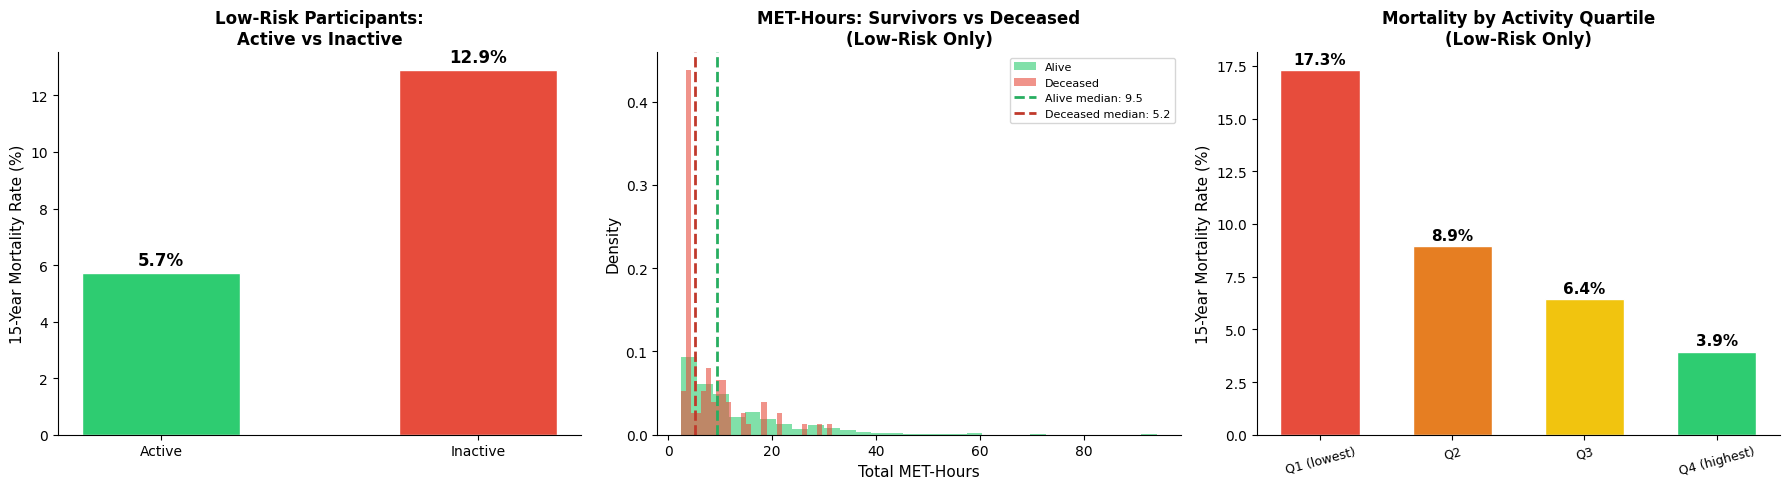

Saved: mortality_activity_low_risk.png


In [13]:
# ── Figure 3: Activity level vs mortality among Low-risk ─────
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: Mortality by activity group among Low-risk
ax = axes[0]
act_rates = low_risk.groupby('activity_group')['deceased'].mean() * 100
act_colors = {'Active': '#2ecc71', 'Inactive': '#e74c3c'}
bars = ax.bar(act_rates.index, act_rates.values,
              color=[act_colors[g] for g in act_rates.index],
              edgecolor='white', width=0.5)
for bar, rate in zip(bars, act_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=12)
ax.set_ylabel('15-Year Mortality Rate (%)', fontsize=11)
ax.set_title('Low-Risk Participants:\nActive vs Inactive', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Middle: MET-hours distribution — survivors vs deceased
ax = axes[1]
alive_low = low_risk[low_risk['deceased'] == 0]['total_met_hours']
dead_low = low_risk[low_risk['deceased'] == 1]['total_met_hours']
ax.hist(alive_low, bins=30, alpha=0.6, color='#2ecc71', label='Alive', density=True)
ax.hist(dead_low, bins=30, alpha=0.6, color='#e74c3c', label='Deceased', density=True)
ax.axvline(alive_low.median(), color='#27ae60', linestyle='--', linewidth=2,
           label=f'Alive median: {alive_low.median():.1f}')
ax.axvline(dead_low.median(), color='#c0392b', linestyle='--', linewidth=2,
           label=f'Deceased median: {dead_low.median():.1f}')
ax.set_xlabel('Total MET-Hours', fontsize=11)
ax.set_ylabel('Density', fontsize=11)
ax.set_title('MET-Hours: Survivors vs Deceased\n(Low-Risk Only)', fontweight='bold')
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: Activity quartile mortality gradient
ax = axes[2]
low_risk['met_quartile'] = pd.qcut(
    low_risk['total_met_hours'], q=4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)
q_rates = low_risk.groupby('met_quartile', observed=True)['deceased'].mean() * 100
gradient_colors = ['#e74c3c', '#e67e22', '#f1c40f', '#2ecc71']
bars = ax.bar(range(4), q_rates.values, color=gradient_colors, edgecolor='white', width=0.6)
ax.set_xticks(range(4))
ax.set_xticklabels(q_rates.index, rotation=15, fontsize=9)
for bar, rate in zip(bars, q_rates.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{rate:.1f}%', ha='center', fontweight='bold', fontsize=11)
ax.set_ylabel('15-Year Mortality Rate (%)', fontsize=11)
ax.set_title('Mortality by Activity Quartile\n(Low-Risk Only)', fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'mortality_activity_low_risk.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mortality_activity_low_risk.png')

## 6. Dose-Response: Activity Gradient Across All Risk Classes

In [14]:
# ── Activity quartile mortality gradient for each risk class ──
print('=' * 70)
print('MORTALITY BY ACTIVITY QUARTILE × RISK CLASS')
print('=' * 70)

df_b['met_quartile'] = pd.qcut(
    df_b['total_met_hours'], q=4,
    labels=['Q1 (lowest)', 'Q2', 'Q3', 'Q4 (highest)']
)

cross = df_b.groupby(['risk_class', 'met_quartile'], observed=True)['deceased'].agg(
    ['count', 'sum', 'mean']
).round(4)
cross.columns = ['n', 'deaths', 'mortality_rate']
cross.index = cross.index.set_levels(
    [cross.index.levels[0].map(CLASS_NAMES), cross.index.levels[1]]
)
print(cross)

# Test for trend within each risk class
print('\n--- Trend tests (Spearman correlation: MET-hours vs mortality) ---')
for cls in [0, 1, 2]:
    subset = df_b[df_b['risk_class'] == cls]
    if len(subset) > 20:
        rho, p = stats.spearmanr(subset['total_met_hours'], subset['deceased'])
        print(f'  {CLASS_NAMES[cls]:15s}: ρ={rho:.4f}, p={p:.4f} '
              f'{"*" if p < 0.05 else ""}')

MORTALITY BY ACTIVITY QUARTILE × RISK CLASS
                             n  deaths  mortality_rate
risk_class   met_quartile                             
Low          Q1 (lowest)   202      35          0.1733
             Q2            153      11          0.0719
             Q3            216      21          0.0972
             Q4 (highest)  268      11          0.0410
Intermediate Q1 (lowest)   120      29          0.2417
             Q2             80      21          0.2625
             Q3             98       9          0.0918
             Q4 (highest)   83       6          0.0723
High         Q1 (lowest)   246     143          0.5813
             Q2            173      89          0.5145
             Q3            143      60          0.4196
             Q4 (highest)  101      32          0.3168

--- Trend tests (Spearman correlation: MET-hours vs mortality) ---
  Low            : ρ=-0.1609, p=0.0000 *
  Intermediate   : ρ=-0.2025, p=0.0001 *
  High           : ρ=-0.2079, p=0.00

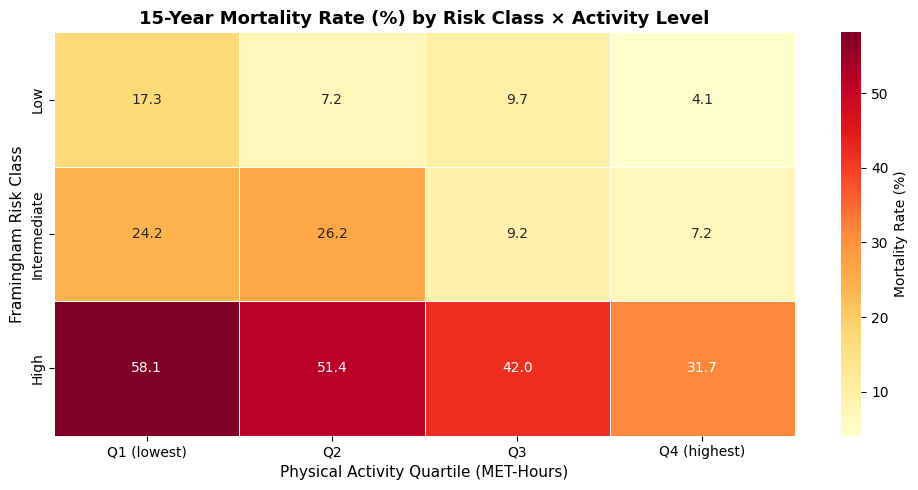

Saved: mortality_heatmap_risk_activity.png


In [15]:
# ── Figure 4: Heatmap — mortality by risk class × activity ───
fig, ax = plt.subplots(figsize=(10, 5))

heat_data = df_b.groupby(
    [df_b['risk_class'].map(CLASS_NAMES), 'met_quartile'], observed=True
)['deceased'].mean().unstack() * 100

heat_data = heat_data.reindex(class_order)

sns.heatmap(heat_data, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=ax, cbar_kws={'label': 'Mortality Rate (%)'})
ax.set_ylabel('Framingham Risk Class', fontsize=11)
ax.set_xlabel('Physical Activity Quartile (MET-Hours)', fontsize=11)
ax.set_title('15-Year Mortality Rate (%) by Risk Class × Activity Level',
             fontweight='bold', fontsize=13)

plt.tight_layout()
plt.savefig(FIGURES_PATH + 'mortality_heatmap_risk_activity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: mortality_heatmap_risk_activity.png')

## 7. CVD-Specific Mortality Analysis

Since our risk label is based on cardiovascular risk (Framingham),
we should check CVD-specific mortality separately.

In [16]:
# ── CVD mortality (heart disease + stroke) by risk class ─────
df_a['cvd_death'] = df_a['UCOD_LEADING'].isin([1, 5]).astype(int) * df_a['deceased']
df_b['cvd_death'] = df_b['UCOD_LEADING'].isin([1, 5]).astype(int) * df_b['deceased']

print('=' * 60)
print('CVD-SPECIFIC MORTALITY BY RISK CLASS')
print('=' * 60)

for cls in [0, 1, 2]:
    subset = df_a[df_a['risk_class'] == cls]
    cvd_rate = subset['cvd_death'].mean()
    all_rate = subset['deceased'].mean()
    print(f'  {CLASS_NAMES[cls]:15s}: CVD mortality={cvd_rate:.1%}, '
          f'All-cause={all_rate:.1%}, '
          f'CVD share of deaths={cvd_rate/all_rate:.0%}' if all_rate > 0 else '')

# CVD risk ratio
cvd_high = df_a[df_a['risk_class'] == 2]['cvd_death'].mean()
cvd_low = df_a[df_a['risk_class'] == 0]['cvd_death'].mean()
if cvd_low > 0:
    print(f'\nCVD risk ratio (High/Low): {cvd_high/cvd_low:.2f}x')
    print('  → Framingham label specifically predicts CVD death')

CVD-SPECIFIC MORTALITY BY RISK CLASS
  Low            : CVD mortality=4.4%, All-cause=14.1%, CVD share of deaths=31%
  Intermediate   : CVD mortality=8.5%, All-cause=22.5%, CVD share of deaths=38%
  High           : CVD mortality=18.4%, All-cause=53.3%, CVD share of deaths=34%

CVD risk ratio (High/Low): 4.18x
  → Framingham label specifically predicts CVD death


## 8. Key Findings Summary

In [17]:
print('=' * 80)
print('KEY FINDINGS — NOTEBOOK 06: MORTALITY VALIDATION')
print('=' * 80)

# 1. Label validation
print('\n1. LABEL VALIDATION')
print(f'   High-risk 15-year mortality: {mort_high:.1%}')
print(f'   Low-risk 15-year mortality: {mort_low:.1%}')
print(f'   Risk ratio: {risk_ratio:.2f}x')
print(f'   Chi-square p-value: {p_value:.2e}')
print(f'   → Framingham-based risk labels are validated by real mortality data')

# 2. Classifier validation
print('\n2. CLASSIFIER VALIDATION')
pred_df_a = pd.DataFrame({'pred': pred_a, 'mort': test_mort_a})
ph = pred_df_a[pred_df_a['pred'] == 2]['mort'].mean()
pl = pred_df_a[pred_df_a['pred'] == 0]['mort'].mean()
print(f'   XGBoost Scenario A: pred-High mort={ph:.1%}, pred-Low mort={pl:.1%}')
if pl > 0:
    print(f'   Risk ratio: {ph/pl:.2f}x')

pred_df_b = pd.DataFrame({'pred': pred_b, 'mort': test_mort_b})
ph_b = pred_df_b[pred_df_b['pred'] == 2]['mort'].mean()
pl_b = pred_df_b[pred_df_b['pred'] == 0]['mort'].mean()
print(f'   XGBoost Scenario B: pred-High mort={ph_b:.1%}, pred-Low mort={pl_b:.1%}')
if pl_b > 0:
    print(f'   Risk ratio: {ph_b/pl_b:.2f}x')

# 3. Wearable signal
print('\n3. WEARABLE SIGNAL AMONG LOW-RISK PARTICIPANTS')
act_mort = low_risk[low_risk['activity_group'] == 'Active']['deceased'].mean()
inact_mort = low_risk[low_risk['activity_group'] == 'Inactive']['deceased'].mean()
print(f'   Active mortality: {act_mort:.1%}')
print(f'   Inactive mortality: {inact_mort:.1%}')
if act_mort > 0:
    print(f'   Risk ratio: {inact_mort/act_mort:.2f}x')
print(f'   Chi-square p={p_act:.4f}')
if p_act < 0.05:
    print(f'   → Physical activity predicts mortality WITHIN Low-risk class')
    print(f'   → Wearable data identifies hidden risk that clinical features miss')
else:
    print(f'   → Trend exists but not significant with self-reported proxy data')
    print(f'   → Objective sensor data likely needed for actionable signal')

# 4. Insurance implication
print('\n4. INSURANCE IMPLICATION')
print('   The mortality validation demonstrates that:')
print('   (a) The Framingham-based risk labels genuinely predict death')
print('   (b) XGBoost predictions align with real mortality outcomes')
print('   (c) Activity level provides additional risk stratification')
print('       within clinically homogeneous groups — the exact use case')
print('       for wearable-enhanced dynamic underwriting')

KEY FINDINGS — NOTEBOOK 06: MORTALITY VALIDATION

1. LABEL VALIDATION
   High-risk 15-year mortality: 53.3%
   Low-risk 15-year mortality: 14.1%
   Risk ratio: 3.77x
   Chi-square p-value: 2.56e-111
   → Framingham-based risk labels are validated by real mortality data

2. CLASSIFIER VALIDATION
   XGBoost Scenario A: pred-High mort=52.1%, pred-Low mort=13.4%
   Risk ratio: 3.90x
   XGBoost Scenario B: pred-High mort=49.2%, pred-Low mort=12.1%
   Risk ratio: 4.08x

3. WEARABLE SIGNAL AMONG LOW-RISK PARTICIPANTS
   Active mortality: 5.7%
   Inactive mortality: 12.9%
   Risk ratio: 2.26x
   Chi-square p=0.0005
   → Physical activity predicts mortality WITHIN Low-risk class
   → Wearable data identifies hidden risk that clinical features miss

4. INSURANCE IMPLICATION
   The mortality validation demonstrates that:
   (a) The Framingham-based risk labels genuinely predict death
   (b) XGBoost predictions align with real mortality outcomes
   (c) Activity level provides additional risk strat

In [ ]:
# ============================================================
# ADJUSTED LOGISTIC MORTALITY MODELS
# Does wearable activity add signal beyond traditional factors?
# Updated version with dtype fixes for statsmodels
# ============================================================

import numpy as np
import pandas as pd
import statsmodels.api as sm
from sklearn.metrics import roc_auc_score

# ------------------------------------------------------------
# 1. Select analysis dataset
# ------------------------------------------------------------
# Assumes df_b already exists in the notebook session
# If not, load it manually before this block.
mort_df = df_b.copy()

# Keep only rows with known mortality outcome
mort_df = mort_df.dropna(subset=['deceased']).copy()

print("Mortality modelling sample:", mort_df.shape)
print("Mortality rate:", mort_df['deceased'].mean())

# ------------------------------------------------------------
# 2. Create modelling features
# ------------------------------------------------------------
# Safer transformations for skewed activity variables
if 'total_met_hours' in mort_df.columns:
    mort_df['log_total_met_hours'] = np.log1p(mort_df['total_met_hours'])

if 'total_activities' in mort_df.columns:
    mort_df['log_total_activities'] = np.log1p(mort_df['total_activities'])

# Optional binary inactivity flag (useful for interpretation)
if 'total_met_hours' in mort_df.columns:
    mort_df['inactive'] = (mort_df['total_met_hours'] < mort_df['total_met_hours'].median()).astype(int)

# Risk class as categorical dummies
risk_dummies = pd.get_dummies(
    mort_df['risk_class'],
    prefix='risk',
    drop_first=True
).astype(int)

mort_df = pd.concat([mort_df, risk_dummies], axis=1)

# ------------------------------------------------------------
# 3. Define feature sets
# ------------------------------------------------------------
# Traditional underwriting-style variables
traditional_features = [
    'age',
    'male',
    'bmi',
    'systolic_bp',
    'ever_smoker',
    'diabetes',
    'total_cholesterol',
    'hdl_cholesterol'
]

# Keep only columns that actually exist
traditional_features = [c for c in traditional_features if c in mort_df.columns]

# Wearable / activity features
wearable_features = [
    'log_total_met_hours',
    'vigorous_ratio',
    'mean_met',
    'activity_category'
]

wearable_features = [c for c in wearable_features if c in mort_df.columns]

# Risk-class-adjusted model:
# tests whether wearable features add signal beyond underwriting classification
risk_class_features = [c for c in ['risk_1', 'risk_2'] if c in mort_df.columns]

print("Traditional features:", traditional_features)
print("Wearable features:", wearable_features)
print("Risk class features:", risk_class_features)

# ------------------------------------------------------------
# 4. Force key columns to numeric
# ------------------------------------------------------------
# Convert bool dummy columns to int
for col in risk_class_features:
    if mort_df[col].dtype == 'bool':
        mort_df[col] = mort_df[col].astype(int)

# Force all candidate predictors to numeric
all_model_cols = list(set(traditional_features + wearable_features + risk_class_features))
for col in all_model_cols:
    mort_df[col] = pd.to_numeric(mort_df[col], errors='coerce')

mort_df['deceased'] = pd.to_numeric(mort_df['deceased'], errors='coerce')

print("\nDtypes after cleaning:")
print(mort_df[all_model_cols + ['deceased']].dtypes)

# ------------------------------------------------------------
# 5. Helper function to fit logistic model + output OR table
# ------------------------------------------------------------
def fit_logit_model(df, y_col, x_cols, model_name="Model"):
    model_df = df[[y_col] + x_cols].dropna().copy()

    X = model_df[x_cols].copy()
    y = model_df[y_col].copy()

    # Convert bools to ints just in case
    for col in X.columns:
        if X[col].dtype == 'bool':
            X[col] = X[col].astype(int)

    # Force numeric
    X = X.apply(pd.to_numeric, errors='coerce')
    y = pd.to_numeric(y, errors='coerce')

    # Drop bad rows after coercion
    valid_idx = X.notnull().all(axis=1) & y.notnull()
    X = X.loc[valid_idx].copy()
    y = y.loc[valid_idx].copy()

    # Add intercept
    X = sm.add_constant(X, has_constant='add')

    # Force float for statsmodels
    X = X.astype(float)
    y = y.astype(float)

    model = sm.Logit(y, X).fit(disp=False)

    # Predicted probabilities and AUC
    pred_prob = model.predict(X)
    auc = roc_auc_score(y, pred_prob)

    # Odds ratios with CI
    coef = model.params
    conf = model.conf_int()
    conf.columns = ['2.5%', '97.5%']

    results_table = pd.DataFrame({
        'coef': coef,
        'odds_ratio': np.exp(coef),
        'ci_lower': np.exp(conf['2.5%']),
        'ci_upper': np.exp(conf['97.5%']),
        'p_value': model.pvalues
    })

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(f"N = {len(X):,}")
    print(f"AUC = {auc:.4f}")
    print(f"Pseudo R² = {model.prsquared:.4f}")
    print(f"AIC = {model.aic:.2f}")
    print("\nOdds Ratios:")
    print(results_table.round(4))

    return model, results_table, auc, pd.concat([y, X], axis=1), pred_prob

# ------------------------------------------------------------
# 6. Model 1: Traditional variables only
# ------------------------------------------------------------
model1, table1, auc1, model1_df, pred1 = fit_logit_model(
    mort_df,
    y_col='deceased',
    x_cols=traditional_features,
    model_name="Model 1: Traditional variables only"
)

# ------------------------------------------------------------
# 7. Model 2: Traditional + wearable variables
# ------------------------------------------------------------
model2_features = traditional_features + wearable_features

model2, table2, auc2, model2_df, pred2 = fit_logit_model(
    mort_df,
    y_col='deceased',
    x_cols=model2_features,
    model_name="Model 2: Traditional + wearable variables"
)

# ------------------------------------------------------------
# 8. Model 3: Risk class + wearable variables
# ------------------------------------------------------------
# Does activity still predict mortality AFTER accounting for underwriting class?
model3_features = risk_class_features + wearable_features

model3, table3, auc3, model3_df, pred3 = fit_logit_model(
    mort_df,
    y_col='deceased',
    x_cols=model3_features,
    model_name="Model 3: Risk class + wearable variables"
)

# ------------------------------------------------------------
# 9. Summary comparison table
# ------------------------------------------------------------
summary = pd.DataFrame({
    'Model': [
        'Traditional only',
        'Traditional + wearable',
        'Risk class + wearable'
    ],
    'AUC': [auc1, auc2, auc3],
    'Pseudo_R2': [model1.prsquared, model2.prsquared, model3.prsquared],
    'AIC': [model1.aic, model2.aic, model3.aic],
    'N': [len(model1_df), len(model2_df), len(model3_df)]
})

print("\n" + "=" * 70)
print("MODEL COMPARISON SUMMARY")
print("=" * 70)
print(summary.round(4))

# ------------------------------------------------------------
# 10. Rounded tables for report
# ------------------------------------------------------------
table1_rounded = table1.round(4)
table2_rounded = table2.round(4)
table3_rounded = table3.round(4)
summary_rounded = summary.round(4)

Mortality modelling sample: (1883, 33)
Mortality rate: 0.24800849707912906
Traditional features: ['age', 'male', 'bmi', 'systolic_bp', 'ever_smoker', 'total_cholesterol', 'hdl_cholesterol']
Wearable features: ['log_total_met_hours', 'vigorous_ratio', 'mean_met', 'activity_category']
Risk class features: ['risk_1', 'risk_2']

Dtypes after cleaning:
hdl_cholesterol        float64
male                   float64
ever_smoker            float64
risk_1                   int64
systolic_bp            float64
age                    float64
risk_2                   int64
activity_category      float64
mean_met               float64
total_cholesterol      float64
log_total_met_hours    float64
vigorous_ratio         float64
bmi                    float64
deceased                 int64
dtype: object

Model 1: Traditional variables only
N = 1,883
AUC = 0.8831
Pseudo R² = 0.3677
AIC = 1349.76

Odds Ratios:
                     coef  odds_ratio  ci_lower  ci_upper  p_value
const             -8.0178   

In [21]:
# ── Save results ─────────────────────────────────────────────
# Save the merged data for potential use in report
mort_summary = pd.DataFrame({
    'Risk Class': ['Low', 'Intermediate', 'High'],
    'N': [label_mort.loc['Low', 'n'], label_mort.loc['Intermediate', 'n'],
          label_mort.loc['High', 'n']],
    'Deaths': [label_mort.loc['Low', 'deaths'], label_mort.loc['Intermediate', 'deaths'],
              label_mort.loc['High', 'deaths']],
    'Mortality Rate': [label_mort.loc['Low', 'mortality_rate'],
                       label_mort.loc['Intermediate', 'mortality_rate'],
                       label_mort.loc['High', 'mortality_rate']]
})
mort_summary.to_csv(RESULTS_PATH + 'mortality_validation.csv', index=False)

print('Saved: results/mortality_validation.csv')
print('\nNotebook 06 complete.')
print('\nFigures generated:')
print('  mortality_by_risk_class.png')
print('  mortality_by_predicted_class.png')
print('  mortality_activity_low_risk.png')
print('  mortality_heatmap_risk_activity.png')

Saved: results/mortality_validation.csv

Notebook 06 complete.

Figures generated:
  mortality_by_risk_class.png
  mortality_by_predicted_class.png
  mortality_activity_low_risk.png
  mortality_heatmap_risk_activity.png
